In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define the Sensor Constraints
sample_rate = 1000  # Microphones recording 1000 times per second
duration = 2.0      # Recording a 2-second echo
t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)

# 2. Define the Physics (Rock Frequencies)
# Sandstone returns a low frequency. Shale returns a high frequency.
freq_sandstone = 20.0  # Hz
freq_shale = 85.0      # Hz

# 3. Generate the Pure Sound Waves
wave_sand = np.sin(2 * np.pi * freq_sandstone * t)
wave_shale = np.sin(2 * np.pi * freq_shale * t)

# 4. Apply Real-World Physics (Attenuation & Noise)
# Sound dies out over time underground (exponential decay)
decay_factor = np.exp(-1.5 * t)

# The Earth is noisy. We add Gaussian white noise to corrupt the signal.
ambient_noise = np.random.normal(0, 0.6, len(t))



In [3]:

# 5. The Final Raw Signals
raw_sandstone_echo = (wave_sand * decay_factor) + ambient_noise
raw_shale_echo = (wave_shale * decay_factor) + ambient_noise


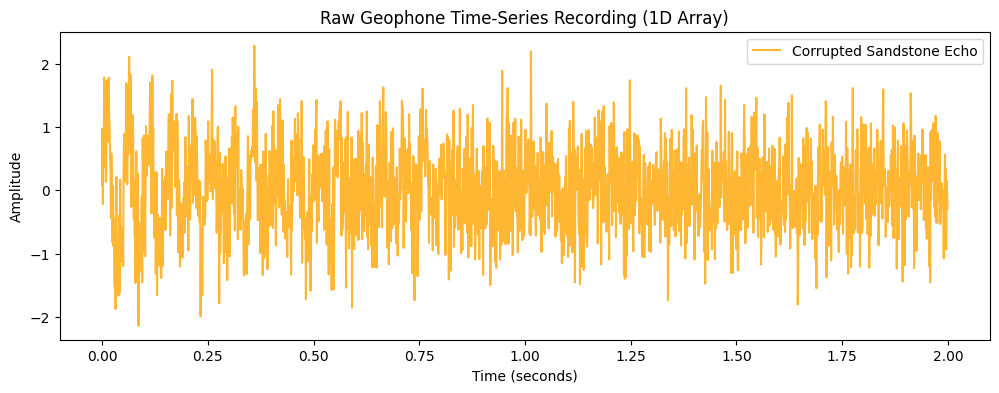

In [4]:
# 6. Visualize the Mess
plt.figure(figsize=(12, 4))
plt.plot(t, raw_sandstone_echo, label="Corrupted Sandstone Echo", color="orange", alpha=0.8)
plt.title("Raw Geophone Time-Series Recording (1D Array)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

# 7. Save to disk so your pipeline can ingest it later
np.save("geophone_001_raw.npy", raw_sandstone_echo)

Extracted Dominant Frequency: 20.0 Hz


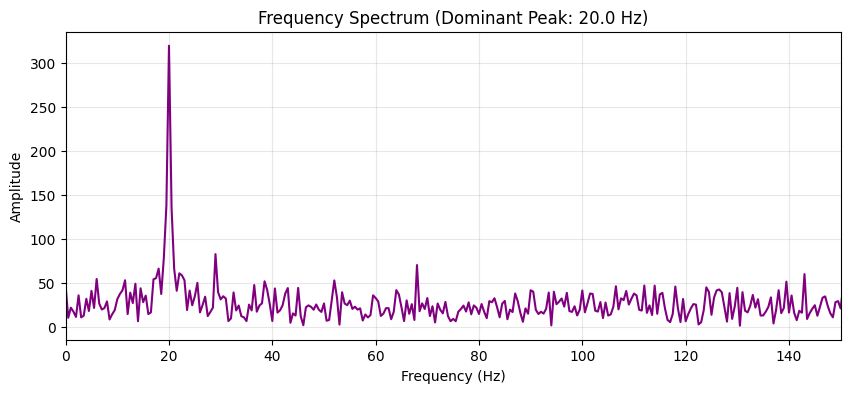

In [5]:


# 1. Load the raw binary data
# This represents reading the tape from the geophone
raw_echo = np.load("geophone_001_raw.npy")

# We need to know the original sample rate to calculate frequencies accurately
sample_rate = 1000 
N = len(raw_echo) # Total number of data points (2000)

# 2. The Fast Fourier Transform (FFT)
# This converts the 1D time array into a complex frequency matrix
fft_result = np.fft.fft(raw_echo)

# 3. Calculate the actual frequency bins (the X-axis for our spectrum)
frequencies = np.fft.fftfreq(N, d=1/sample_rate)

# 4. Clean up the math
# FFT mirrors the output (positive and negative frequencies). We only need the positive half.
positive_freqs = frequencies[:N//2]
# The FFT output is complex numbers. We need the absolute magnitude (amplitude).
amplitudes = np.abs(fft_result)[:N//2]

# 5. Extract Feature 1: The Dominant Frequency
# Find the exact index where the amplitude is the highest
max_amplitude_index = np.argmax(amplitudes)
dominant_frequency = positive_freqs[max_amplitude_index]

print(f"Extracted Dominant Frequency: {dominant_frequency} Hz")

# 6. Visualize the Frequency Domain
plt.figure(figsize=(10, 4))
plt.plot(positive_freqs, amplitudes, color='purple')
plt.title(f"Frequency Spectrum (Dominant Peak: {dominant_frequency} Hz)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.xlim(0, 150) # Zoom in on the relevant frequencies
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
import pandas as pd
from scipy.stats import entropy

# --- Assuming 'positive_freqs' and 'amplitudes' are already calculated from your FFT script ---

# Feature 2: Max Amplitude
# How loud was the loudest specific frequency?
max_amplitude = np.max(amplitudes)

# Feature 3: Spectral Entropy
# This measures the "chaos" of the signal. 
# We must normalize the amplitudes into a probability distribution (summing to 1) to calculate Shannon Entropy.
probability_distribution = amplitudes / np.sum(amplitudes)
spectral_entropy = entropy(probability_distribution)

print(f"Max Amplitude: {max_amplitude:.2f}")
print(f"Spectral Entropy: {spectral_entropy:.4f}")

# --- Building the Machine Learning Matrix ---
# Now we take these raw mathematical outputs and structure them into a Pandas DataFrame.
# This is the exact format your ML algorithms will consume.

feature_vector = {
    "Geophone_ID": "GEO-001",
    "X_Coord": 542010.5, # Mock coordinate
    "Y_Coord": 4320912.2, # Mock coordinate
    "Z_Depth": 1500.5,    # Mock depth
    "Dom_Freq_Hz": dominant_frequency,
    "Max_Amp": max_amplitude,
    "Spectral_Entropy": spectral_entropy
}

df = pd.DataFrame([feature_vector])

print("\n--- Final Tabular Feature Matrix ---")
print(df.to_string())

Max Amplitude: 319.44
Spectral Entropy: 6.7362

--- Final Tabular Feature Matrix ---
  Geophone_ID   X_Coord    Y_Coord  Z_Depth  Dom_Freq_Hz     Max_Amp  Spectral_Entropy
0     GEO-001  542010.5  4320912.2   1500.5         20.0  319.442178          6.736177


In [8]:
import numpy as np
import pandas as pd
from scipy.stats import entropy
import random

# Setup constraints
sample_rate = 1000
duration = 2.0
t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)
num_samples = 100000 # We will generate 1,000 rows of data
data_rows = []

print("Starting heavy DSP batch processing for 1,000 samples...")

for i in range(num_samples):
    # 1. Randomly assign a spatial coordinate for this sensor
    x_coord = random.uniform(542000, 543000)
    y_coord = random.uniform(4320000, 4321000)
    z_depth = random.uniform(1000, 3000)
    
    # 2. Randomly decide what rock this sensor is looking at (The Ground Truth)
    lithology = random.choice(["Sandstone", "Shale", "Oil_Reservoir"])
    
    # 3. Generate the specific wave physics based on the rock type
    ambient_noise = np.random.normal(0, 0.6, len(t))
    decay = np.exp(-1.5 * t)
    
    if lithology == "Sandstone":
        # Low frequency, clean echo
        wave = np.sin(2 * np.pi * random.uniform(18, 25) * t) * decay + ambient_noise
    elif lithology == "Shale":
        # High frequency, clean echo
        wave = np.sin(2 * np.pi * random.uniform(75, 90) * t) * decay + ambient_noise
    elif lithology == "Oil_Reservoir":
        # Oil absorbs sound: High decay, chaotic mixed frequencies
        heavy_decay = np.exp(-3.5 * t) 
        wave = (np.sin(2 * np.pi * 15 * t) + np.sin(2 * np.pi * 45 * t)) * heavy_decay + (ambient_noise * 1.5)
        
    # 4. Phase 2 Logic: Run the FFT on the generated wave
    fft_result = np.fft.fft(wave)
    frequencies = np.fft.fftfreq(len(wave), d=1/sample_rate)
    
    positive_freqs = frequencies[:len(wave)//2]
    amplitudes = np.abs(fft_result)[:len(wave)//2]
    
    # 5. Extract Features
    dom_freq = positive_freqs[np.argmax(amplitudes)]
    max_amp = np.max(amplitudes)
    
    # Calculate Spectral Entropy safely
    prob_dist = amplitudes / np.sum(amplitudes)
    spec_entropy = entropy(prob_dist)
    
    # 6. Append to our dataset
    data_rows.append({
        "Sensor_ID": f"GEO-{i}",
        "X": round(x_coord, 2),
        "Y": round(y_coord, 2),
        "Z_Depth": round(z_depth, 2),
        "Dom_Freq_Hz": round(dom_freq, 2),
        "Max_Amp": round(max_amp, 2),
        "Spectral_Entropy": round(spec_entropy, 4),
        "Target_Lithology": lithology
    })

# 7. Convert to DataFrame and Save
df = pd.DataFrame(data_rows)
df.to_csv("seismic_dataset.csv", index=False)

print("\nSuccess! Generated 'seismic_dataset.csv' with 1,000 rows.")
print(df.head())

Starting heavy DSP batch processing for 1,000 samples...

Success! Generated 'seismic_dataset.csv' with 1,000 rows.
  Sensor_ID          X           Y  Z_Depth  Dom_Freq_Hz  Max_Amp  \
0     GEO-0  542686.29  4320351.58  2843.36         45.0   168.30   
1     GEO-1  542899.47  4320367.86  2966.22         15.0   150.68   
2     GEO-2  542517.38  4320844.49  1598.14         21.0   343.61   
3     GEO-3  542356.61  4320145.88  2031.15         15.0   147.24   
4     GEO-4  542533.46  4320320.18  1644.76         76.5   264.69   

   Spectral_Entropy Target_Lithology  
0            6.7513    Oil_Reservoir  
1            6.7626    Oil_Reservoir  
2            6.7304        Sandstone  
3            6.7625    Oil_Reservoir  
4            6.7305            Shale  
